In [9]:
import sys
import os
import pandas as pd

sys.path.append('../src/scripts')
sys.path.append('../src/classes')
from simulation import Simulation
from config import get_simulation_number
from data_scraping_in_results import scraper

In [10]:
mobility_file_path = '../src/sumo/csv/train_single.csv'
edge_file_path = '../src/inputs/train/edge_servers.json'
vehicle_file_path = '../src/inputs/train/vehicles_single.json'


In [11]:
_proposed="proposed"
_local= "local_only"
_offload = "offload_only"
_random = "random"
algorithms = [_proposed,_local,_offload,_random]
simulation_number = "trainset"
report_paths = {}

for a in algorithms:
    report_paths[a] = ('../results/reports/'+str(simulation_number)+'_report_'+a+'_test.csv')
q_table_path = '../results/q_table/'+str(simulation_number)+'_q_table_proposed'

#overwrite specific report addresses for proposed
proposed_test_sim_number=98
proposed_test_number='train'
if(proposed_test_number != 'train'):
    report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_test_'+str(proposed_test_number)+'.csv'
else:
    report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_train.csv'


num_of_cars=20
end_time_limit=-1
# should_update_q_table = False
print(report_paths)

{'proposed': '../results/reports/98_report_proposed_train.csv', 'local_only': '../results/reports/trainset_report_local_only_test.csv', 'offload_only': '../results/reports/trainset_report_offload_only_test.csv', 'random': '../results/reports/trainset_report_random_test.csv'}


In [12]:
scrapers={}
for a in algorithms:
    scrapers[a] = scraper(report_paths[a],num_of_cars,end_time_limit)

---------------------------------------------
../results/reports/98_report_proposed_train.csv
No time limit
Header --->
   vehicle_id  task_id  execution_location     size    distance  \
0           1        1                   0  8000000  180.123622   
1           1        2                   0  5000000  178.219525   
2           1        4                   1  4000000  174.280050   
3           1        3                   1  8000000  183.890262   
4           1        5                   0  9000000  153.931249   

   transfer_rate  execution_cycles  start_time  end_time  release_time  \
0   0.000000e+00        5000000000           1      5001             1   
1   0.000000e+00        5000000000        5001     10001          3001   
2   1.451372e+06        5000000000       12222     13222          9001   
3   1.173206e+06       10000000000       13222     15222          6001   
4   0.000000e+00        4000000000       12001     16001         12001   

   response_time  transmission_t

In [13]:
averages = {}
for a in algorithms:
    print("=========================================")
    print(a,"------->")
    averages[a] = scrapers[a].calc_average_all(False)

final_df = pd.concat(averages, names=['Algorithm'])
print(final_df)



proposed ------->
local_only ------->
offload_only ------->
random ------->
Algorithm                  
proposed      response_time     19391.319061
              total_energy          0.930689
local_only    response_time    250495.790740
              total_energy          0.598948
offload_only  response_time     75399.476518
              total_energy          1.274470
random        response_time     20477.677588
              total_energy          0.919905
dtype: float64


In [14]:
for a in algorithms:
    print("=========================================")
    print(a,"----------AVERAGED----->")
    scrapers[a].calc_average_for_each_car()

proposed ----------AVERAGED----->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1            24023.659574        2711.820669     3581.155015   
2            15518.422492        2097.066869     3578.723404   
3            27592.735202        2003.563863     3647.975078   
4            15853.069697        1716.881818     3471.515152   
5            12455.867069        2040.655589     3422.356495   
6            20829.242902        1733.564669     3649.211356   
7            13123.969136        1970.101852     3287.654321   
8            34472.754777        1750.541401     3658.598726   
9            12807.753049        1890.975610     3370.731707   
10           21367.469512        2344.975610     3571.951220   
11           10989.914110        2645.276074     3251.533742   
12           33452.650155        2433.346749     3650.154799   
13           10830.506061        2852.984848     3340.000000   
14    

In [15]:
for a in algorithms:
    print("=========================================")
    print(a,"----TOTAL------->")
    scrapers[a].calc_sum_for_each_car()

proposed ----TOTAL------->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1                 7903784             892189         1178200   
2                 5105561             689935         1177400   
3                 8857268             643144         1171000   
4                 5231513             566571         1145600   
5                 4122892             675457         1132800   
6                 6602870             549540         1156800   
7                 4252166             638313         1065200   
8                10824445             549670         1148800   
9                 4200943             620240         1105600   
10                7008530             769152         1171600   
11                3582712             862360         1060000   
12               10805206             785971         1179000   
13                3574067             941485         1102200   
14           

            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1                40698000                  0          998000   
2                39560000                  0          998000   
3                42324000                  0          992000   
4                41937000                  0          995000   
5                42583000                  0          996000   
6                39344000                  0          994000   
7                41744000                  0          999000   
8                40873000                  0          995000   
9                40247000                  0          996000   
10               42893000                  0          998000   
11               39921000                  0          998000   
12               43903000                  0          994000   
13               43296000                  0          996000   
14               44930000               

proposed -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1520             1519.0             1119.0           400.0               0.0   
1701             1700.0             1300.0           400.0               0.0   
2001             2000.0                0.0          2000.0               0.2   
2220             2219.0              819.0          1400.0               0.0   
4001             4000.0                0.0          4000.0               0.4   
...                 ...                ...             ...               ...   
998169           5168.0             4368.0           800.0               0.0   
998217           2216.0              416.0          1800.0               0.0   
998348           2347.0              947.0          1400.0               0.0   
999001          63000.0                0.0          7000.0               0.7   
999042    

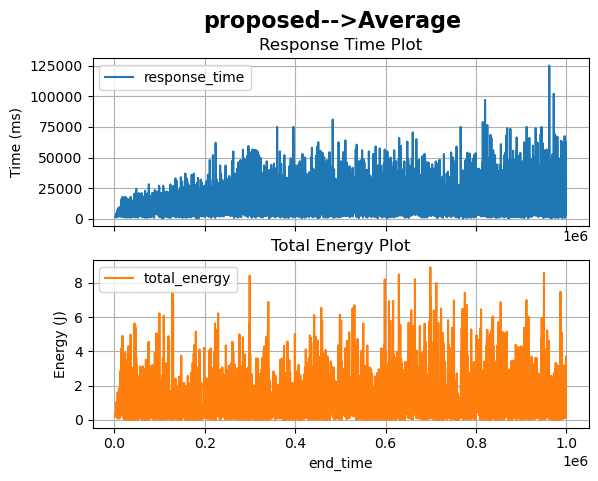

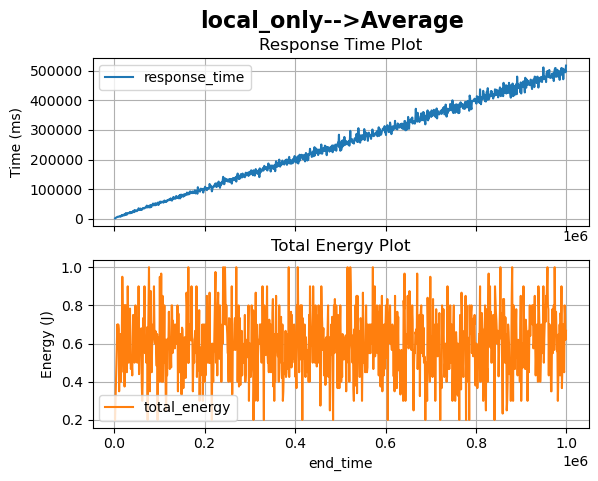

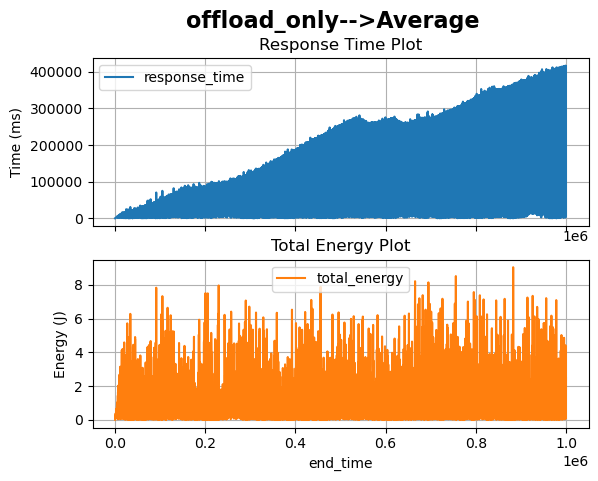

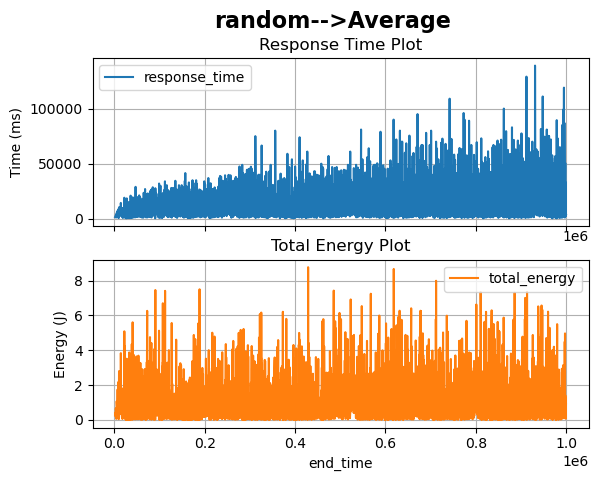

In [16]:
for a in algorithms:
    print("=========================================")
    print(a,"-------AVERAGE----->")
    scrapers[a].calc_average_for_each_end_time(plot=True,plot_title=a+"-->"+"Average")

proposed -------SUM----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1520               1519               1119             400               0.0   
1701               1700               1300             400               0.0   
2001               2000                  0            2000               0.2   
2220               2219                819            1400               0.0   
4001              12000                  0           12000               1.2   
...                 ...                ...             ...               ...   
998169             5168               4368             800               0.0   
998217             2216                416            1800               0.0   
998348             2347                947            1400               0.0   
999001           189000                  0           21000               2.1   
999042        

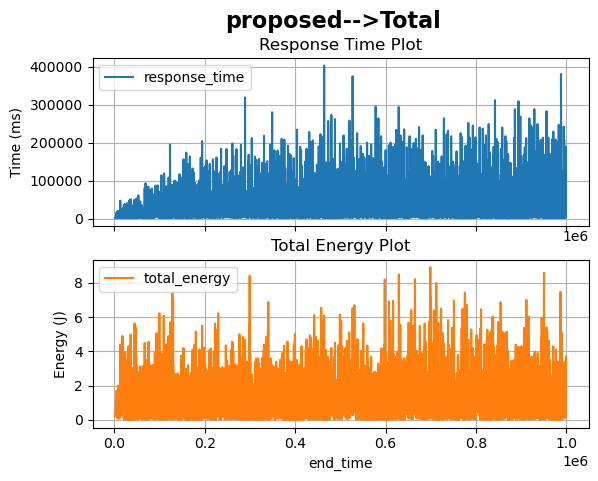

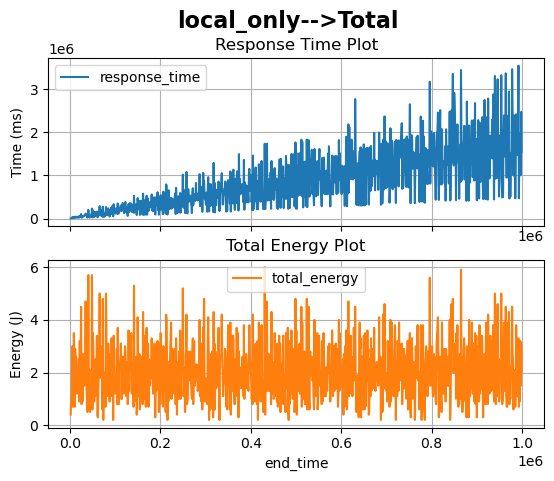

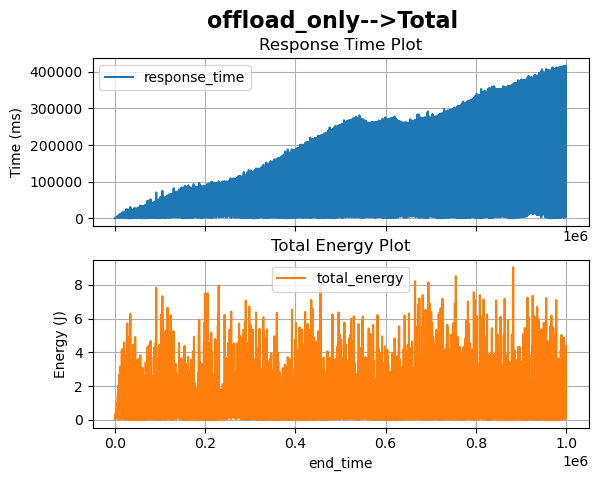

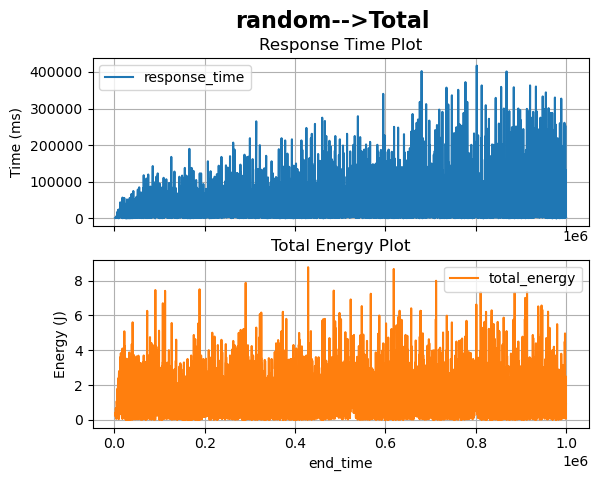

In [17]:
for a in algorithms:
    print("=========================================")
    print(a,"-------SUM----->")
    scrapers[a].calc_sum_for_each_end_time(plot=True,plot_title=a+"-->"+"Total")